# 05_LogisticRegression.ipynb

# Section 1 — Introduction

---

# What is Logistic Regression?

Logistic Regression is a **supervised machine learning algorithm used for classification problems**. Unlike Linear Regression, which predicts a continuous value, Logistic Regression predicts **the probability that an input belongs to a particular class**.

For a binary classification problem:

```text
Class 0 → Negative
Class 1 → Positive
```

Instead of directly predicting the class, it first predicts a probability.

Example:

| Probability | Predicted Class |
| ----------- | --------------- |
| 0.95        | 1               |
| 0.82        | 1               |
| 0.61        | 1               |
| 0.42        | 0               |
| 0.18        | 0               |

A threshold (usually **0.5**) converts the probability into the final class prediction.

```text
Probability ≥ 0.5  → Class 1

Probability < 0.5  → Class 0
```

> **Important:** Logistic Regression is a **classification algorithm**, despite having "Regression" in its name. The name comes from the fact that it models a regression equation internally before applying the Sigmoid function.

---

# Why do we need Logistic Regression?

Suppose we want to classify whether an email is spam.

| Email    | Output |
| -------- | ------ |
| Spam     | 1      |
| Not Spam | 0      |

If we use Linear Regression:

```text
Prediction = 1.8
Prediction = -0.7
Prediction = 3.4
```

These outputs don't make sense because probabilities should always lie between **0 and 1**.

Logistic Regression solves this by converting any real-valued output into a valid probability.

---

## Problems with Linear Regression for Classification

| Problem                           | Why It Happens                               |
| --------------------------------- | -------------------------------------------- |
| Predictions can be less than 0    | No output restriction                        |
| Predictions can be greater than 1 | No upper bound                               |
| Doesn't produce probabilities     | Output is continuous                         |
| Sensitive to outliers             | Regression line shifts easily                |
| Poor decision boundary            | Optimizes MSE instead of classification loss |

---

# Mathematical Intuition

Logistic Regression is actually built on top of a linear equation.

First it calculates

[
z = w_1x_1+w_2x_2+\cdots+w_nx_n+b
]

This is exactly the same linear combination used in Linear Regression.

Here,

| Symbol | Meaning                           |
| ------ | --------------------------------- |
| (x_i)  | Feature                           |
| (w_i)  | Weight of feature                 |
| (b)    | Bias                              |
| (z)    | Raw score (also called **logit**) |

Notice that

[
z \in (-\infty,\infty)
]

It can become any value.

Example:

```text
-15
-3
0
5
27
150
```

These are **not probabilities**.

So Logistic Regression applies the **Sigmoid Function**.

---

# Sigmoid Function

The Sigmoid function is

[
\sigma(z)=\frac{1}{1+e^{-z}}
]

Its job is simple:

> Convert any real number into a value between **0 and 1**.

---

### Some Example Values

| z   | Sigmoid(z) |
| --- | ---------- |
| -10 | 0.000045   |
| -5  | 0.0067     |
| -2  | 0.119      |
| -1  | 0.269      |
| 0   | 0.5        |
| 1   | 0.731      |
| 2   | 0.881      |
| 5   | 0.993      |
| 10  | 0.99995    |

Notice:

* Very negative → close to 0
* Zero → exactly 0.5
* Very positive → close to 1

This makes it perfect for probability prediction.

---

# Complete Prediction Flow

```text
Input Features
      │
      ▼
Linear Equation
z = wx + b
      │
      ▼
Sigmoid Function
      │
      ▼
Probability (0–1)
      │
      ▼
Threshold (0.5)
      │
      ▼
Final Class
```

---

# Why is the Sigmoid Function Used?

| Property                      | Benefit                                 |
| ----------------------------- | --------------------------------------- |
| Output always between 0 and 1 | Valid probability                       |
| Smooth curve                  | Easy to optimize                        |
| Differentiable                | Gradient-based optimization is possible |
| Monotonic                     | Larger score → Higher probability       |

---

# Decision Boundary

The default decision boundary is

```text
Probability ≥ 0.5 → Class 1

Probability < 0.5 → Class 0
```

Since

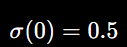

the decision boundary is equivalent to

```text
z ≥ 0 → Class 1

z < 0 → Class 0
```

This is why Logistic Regression ultimately learns a **linear decision boundary** in the feature space.

---

# Advantages

| Advantage                                       | Explanation                      |
| ----------------------------------------------- | -------------------------------- |
| Fast training                                   | Efficient even on large datasets |
| Simple to understand                            | Easy to interpret coefficients   |
| Predicts probabilities                          | Useful when confidence matters   |
| Less prone to overfitting (with regularization) | Better generalization            |
| Works well on linearly separable data           | Strong baseline model            |

---

# Disadvantages

| Disadvantage                         | Explanation                                        |
| ------------------------------------ | -------------------------------------------------- |
| Linear decision boundary             | Cannot capture complex nonlinear patterns          |
| Needs good feature engineering       | Performance depends on input features              |
| Sensitive to multicollinearity       | Highly correlated features can affect coefficients |
| Feature scaling recommended          | Helps optimization converge faster                 |
| Can underperform on complex datasets | Tree-based or neural models may perform better     |

---

# When to Use

Use Logistic Regression when:

* Binary classification
* Baseline classification model
* Need probability estimates
* Model interpretability is important
* Relationship between features and target is approximately linear

Examples:

* Spam detection
* Disease diagnosis
* Customer churn prediction
* Loan approval
* Fraud detection

---

# When NOT to Use

Avoid Logistic Regression when:

* Data is highly nonlinear
* Complex image classification
* Large NLP tasks
* Relationships cannot be approximated by a linear decision boundary
* Very complex feature interactions exist without feature engineering

---

# Applications

| Domain        | Example            |
| ------------- | ------------------ |
| Healthcare    | Disease prediction |
| Banking       | Credit approval    |
| Finance       | Fraud detection    |
| Marketing     | Customer churn     |
| Email         | Spam detection     |
| Manufacturing | Defect detection   |

---

# Linear Regression vs Logistic Regression

| Feature             | Linear Regression  | Logistic Regression |
| ------------------- | ------------------ | ------------------- |
| Problem Type        | Regression         | Classification      |
| Output              | Continuous value   | Probability         |
| Output Range        | (-∞, ∞)            | (0, 1)              |
| Activation Function | None               | Sigmoid             |
| Loss Function       | Mean Squared Error | Log Loss            |
| Prediction          | Numeric value      | Class label         |

---

## Key Takeaways

* Logistic Regression is a **classification algorithm**.
* It predicts **probabilities**, not continuous values.
* It first computes a **linear equation** (`z = wx + b`).
* The **Sigmoid function** converts `z` into a probability.
* A threshold (usually **0.5**) converts the probability into the predicted class.
* Despite its name, Logistic Regression is **not used for regression tasks**.

# Section 2 — Import & Constructor

---

# Import

The `LogisticRegression` class is available inside `sklearn.linear_model`.

```python
from sklearn.linear_model import LogisticRegression
```

---

# Constructor

```python
LogisticRegression(
    penalty='l2',
    *,
    dual=False,
    tol=1e-4,
    C=1.0,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    multi_class='deprecated',
    verbose=0,
    warm_start=False,
    n_jobs=None,
    l1_ratio=None
)
```

You won't need every parameter in day-to-day ML. Let's cover the important ones first.

---

# Important Parameters

| Parameter       | Default   | Description                        | Common Usage                      |
| --------------- | --------- | ---------------------------------- | --------------------------------- |
| `penalty`       | `'l2'`    | Type of regularization             | Keep `'l2'`                       |
| `C`             | `1.0`     | Inverse of regularization strength | Tune during model optimization    |
| `solver`        | `'lbfgs'` | Optimization algorithm             | Keep `'lbfgs'`                    |
| `max_iter`      | `100`     | Maximum optimization iterations    | Increase to 500 or 1000 if needed |
| `fit_intercept` | `True`    | Learn bias term                    | Keep `True`                       |
| `class_weight`  | `None`    | Handle imbalanced classes          | `'balanced'`                      |
| `random_state`  | `None`    | Controls randomness                | Set for reproducibility           |
| `warm_start`    | `False`   | Reuse previous solution            | Rarely used                       |

---

# Parameter Details

---

## 1. penalty

Regularization prevents the model from learning overly large coefficients, helping reduce overfitting.

```python
penalty='l2'
```

Possible values:

| Value          | Meaning                                                |
| -------------- | ------------------------------------------------------ |
| `'l2'`         | Default and most commonly used                         |
| `'l1'`         | Produces sparse models (some coefficients become zero) |
| `'elasticnet'` | Combination of L1 and L2                               |
| `None`         | No regularization                                      |

Example:

```python
model = LogisticRegression(penalty='l2')
```

> **Recommendation:** Use `'l2'` unless you specifically need feature selection with L1.

---

## 2. C

This is one of the **most important hyperparameters**.

It controls the amount of regularization.

> **Important:** `C` is the **inverse** of regularization strength.

Meaning:

| C Value | Regularization | Model Complexity   |
| ------- | -------------- | ------------------ |
| 0.01    | Very High      | Simpler model      |
| 0.1     | High           | Simpler            |
| 1.0     | Default        | Balanced           |
| 10      | Low            | More complex       |
| 100     | Very Low       | Highest complexity |

Visual intuition:

```text
Small C
↓
More Regularization
↓
Smaller Coefficients
↓
Lower Overfitting

-------------------------

Large C
↓
Less Regularization
↓
Larger Coefficients
↓
Higher Risk of Overfitting
```

Example:

```python
model = LogisticRegression(C=0.5)
```

---

## 3. solver

The solver is the optimization algorithm used to find the best coefficients.

You don't need to know its mathematical details yet, but you should know when to use each one.

| Solver              | Supports           | When to Use                           |
| ------------------- | ------------------ | ------------------------------------- |
| `'lbfgs'`           | L2                 | Default, works for most datasets      |
| `'liblinear'`       | L1, L2             | Small datasets, binary classification |
| `'newton-cg'`       | L2                 | Large datasets                        |
| `'newton-cholesky'` | L2                 | Efficient when samples >> features    |
| `'sag'`             | L2                 | Large datasets                        |
| `'saga'`            | L1, L2, ElasticNet | Large datasets and ElasticNet         |

Example:

```python
model = LogisticRegression(solver='lbfgs')
```

### Solver Compatibility

Not every solver supports every penalty.

| Penalty    | Supported Solvers   |
| ---------- | ------------------- |
| L2         | All major solvers   |
| L1         | `liblinear`, `saga` |
| ElasticNet | `saga` only         |
| None       | Most modern solvers |

If you choose an incompatible combination, scikit-learn raises a `ValueError`.

---

## 4. max_iter

Logistic Regression is trained using an iterative optimization algorithm.

`max_iter` specifies the maximum number of iterations allowed.

```python
max_iter=100
```

If the model doesn't converge within these iterations, you'll see:

```text
ConvergenceWarning
```

Example:

```python
model = LogisticRegression(max_iter=500)
```

> **Recommendation:** Use `500` or `1000` for medium or large datasets to avoid convergence warnings.

---

## 5. fit_intercept

Determines whether the model learns the bias (intercept).

```python
fit_intercept=True
```

Model equation:

**`z = wx + b`**

If:

```python
fit_intercept=False
```

then the equation becomes:

**`z = wx`**

In most real-world problems, the bias term is important.

> **Recommendation:** Keep `True`.

---

## 6. class_weight

Useful for **imbalanced datasets**.

Example dataset:

| Class | Samples |
| ----- | ------- |
| 0     | 980     |
| 1     | 20      |

Without class weighting, the model may mostly predict class 0.

Using:

```python
class_weight='balanced'
```

automatically assigns higher importance to the minority class.

Example:

```python
model = LogisticRegression(class_weight='balanced')
```

Use when:

* Fraud detection
* Disease diagnosis
* Spam detection
* Any imbalanced classification problem

| Situation                       | `stratify=y` | `class_weight='balanced'` |
| ------------------------------- | :----------: | :-----------------------: |
| Balanced classes (50/50, 55/45) |     ✅ Yes    |            ❌ No           |
| Slight imbalance (70/30)        |     ✅ Yes    |          ⚠️ Maybe         |
| Moderate imbalance (80/20)      |     ✅ Yes    |         ✅ Usually         |
| Severe imbalance (90/10, 95/5)  |     ✅ Yes    |        ✅ Definitely       |


---

## 7. random_state

Controls randomness in parts of the training process (depending on the solver and settings).

```python
random_state=42
```

Benefits:

* Reproducible results
* Same model each run (when randomness is involved)

Example:

```python
model = LogisticRegression(random_state=42)
```

---

## 8. warm_start

```python
warm_start=False
```

If set to `True`, the model starts training from the previous solution instead of starting from scratch.

Useful when repeatedly fitting the same model with slight parameter changes.

Example:

```python
model = LogisticRegression(warm_start=True)
```

> **Recommendation:** Keep `False` unless you have a specific optimization workflow.

---

# Less Common Parameters

| Parameter           | Purpose                                                            | Usually Change?                  |
| ------------------- | ------------------------------------------------------------------ | -------------------------------- |
| `dual`              | Dual optimization formulation                                      | ❌ Rarely                         |
| `tol`               | Convergence tolerance                                              | ❌ Rarely                         |
| `intercept_scaling` | Scaling for synthetic intercept feature (mainly with `liblinear`)  | ❌ Rarely                         |
| `verbose`           | Print optimization progress                                        | Sometimes for debugging          |
| `n_jobs`            | Number of CPU cores (limited support depending on solver/settings) | Rarely                           |
| `l1_ratio`          | Ratio of L1/L2 for ElasticNet                                      | Only with `penalty='elasticnet'` |

---

# Recommended Settings

### General Binary Classification

```python
model = LogisticRegression(
    random_state=42,
    max_iter=500
)
```

---

### Imbalanced Dataset

```python
model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=500
)
```

---

### L1 Regularization

```python
model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    random_state=42
)
```

---

# Summary Table

| Situation                | Recommended Settings               |
| ------------------------ | ---------------------------------- |
| Most datasets            | `solver='lbfgs', max_iter=500`     |
| Small binary dataset     | `solver='liblinear'`               |
| Imbalanced classes       | `class_weight='balanced'`          |
| Need sparse coefficients | `penalty='l1', solver='liblinear'` |
| Default starting point   | `random_state=42, max_iter=500`    |

# Section 3 — Methods & Attributes

After creating a `LogisticRegression` object, you'll mainly interact with it through its **methods** (actions you perform) and inspect its **attributes** (information learned after training).

> **Important:** Most attributes are available **only after calling `fit()`**. Trying to access them before training raises an `AttributeError`.

---

# Methods

## Important Methods

| Method                 | Purpose                              | Returns     |
| ---------------------- | ------------------------------------ | ----------- |
| `fit(X, y)`            | Train the model                      | `self`      |
| `predict(X)`           | Predict class labels                 | NumPy array |
| `predict_proba(X)`     | Predict class probabilities          | NumPy array |
| `predict_log_proba(X)` | Predict log probabilities            | NumPy array |
| `score(X, y)`          | Compute mean accuracy                | Float       |
| `decision_function(X)` | Raw decision scores (before sigmoid) | NumPy array |
| `get_params()`         | Get constructor parameters           | Dictionary  |
| `set_params()`         | Update parameters                    | `self`      |

These are the methods you'll use in almost every Logistic Regression project.

---

## 1. fit()

Trains the Logistic Regression model.

### Syntax

```python
model.fit(X_train, y_train)
```

### Parameters

| Parameter | Description       |
| --------- | ----------------- |
| `X_train` | Training features |
| `y_train` | Target labels     |

### Returns

The trained model itself (`self`).

### Example

```python
model.fit(X_train, y_train)
```

After this step, the model learns:

* Feature coefficients
* Bias (intercept)
* Class labels

Only after `fit()` can you use prediction methods or access learned attributes.

---

## 2. predict()

Predicts the **final class labels**.

### Syntax

```python
predictions = model.predict(X_test)
```

### Returns

A NumPy array containing predicted classes.

Example:

```text
[1 0 1 1 0]
```

For binary classification, the output usually contains:

```text
0
1
```

---

## 3. predict_proba()

Predicts the probability of each class.

### Syntax

```python
probabilities = model.predict_proba(X_test)
```

### Returns

For binary classification:

```text
[
 [0.02 0.98]
 [0.85 0.15]
 [0.30 0.70]
]
```

Each row represents:

```text
[Probability of Class 0,
 Probability of Class 1]
```

Notice:

```text
0.02 + 0.98 = 1

0.85 + 0.15 = 1
```

The probabilities in each row always sum to **1**.

### When to use

Use `predict_proba()` when:

* You need confidence scores.
* You want to change the decision threshold (e.g., 0.7 instead of 0.5).
* You're plotting ROC or Precision-Recall curves.

---

## 4. predict_log_proba()

Returns the **logarithm of class probabilities**.

### Syntax

```python
log_prob = model.predict_log_proba(X_test)
```

### Returns

```text
[
 [-3.91 -0.02]
 [-0.16 -1.83]
]
```

### When is it used?

Mostly in advanced probabilistic models or numerical computations.

For most projects, `predict_proba()` is sufficient.

---

## 5. score()

Computes the model's accuracy.

### Syntax

```python
accuracy = model.score(X_test, y_test)
```

Internally, it calculates:

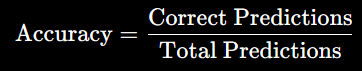

### Example

```python
print(model.score(X_test, y_test))
```

Output:

```text
0.9649
```

Equivalent to:

```python
from sklearn.metrics import accuracy_score

accuracy_score(y_test, model.predict(X_test))
```

---

## 6. decision_function()

Returns the **raw score** before applying the Sigmoid function.

Recall the Logistic Regression pipeline:

```text
wx + b
   ↓
decision_function()
   ↓
Sigmoid
   ↓
Probability
```

### Syntax

```python
scores = model.decision_function(X_test)
```

Example output:

```text
[-4.82
  2.17
  0.64]
```

Interpretation:

* Large positive score → High probability of class 1.
* Large negative score → High probability of class 0.
* Score close to 0 → Prediction is uncertain.

### When is it used?

* ROC curve calculations
* Threshold tuning
* Advanced evaluation

Most beginners will use `predict_proba()` instead.

---

## 7. get_params()

Returns all constructor parameters.

### Syntax

```python
params = model.get_params()
```

Example output:

```python
{
 'C': 1.0,
 'max_iter': 500,
 'solver': 'lbfgs',
 ...
}
```

Useful for:

* Checking current configuration.
* Hyperparameter tuning.
* Debugging.

---

## 8. set_params()

Updates constructor parameters without creating a new model.

### Syntax

```python
model.set_params(max_iter=1000)
```

Useful during hyperparameter tuning.

---

# Attributes

Attributes are values **learned during training**.

> They are created only after calling `fit()`.

---

## Important Attributes

| Attribute           | Description                               |
| ------------------- | ----------------------------------------- |
| `coef_`             | Feature weights                           |
| `intercept_`        | Bias term                                 |
| `classes_`          | Unique class labels                       |
| `n_features_in_`    | Number of input features                  |
| `feature_names_in_` | Feature names (DataFrame input only)      |
| `n_iter_`           | Number of iterations used for convergence |

---

## 1. coef_

Stores the learned coefficients for each feature.

### Syntax

```python
model.coef_
```

Example:

```text
[[ 0.85 -1.12 0.42 2.31]]
```

Interpretation:

| Coefficient     | Meaning                          |
| --------------- | -------------------------------- |
| Positive        | Increases probability of class 1 |
| Negative        | Decreases probability of class 1 |
| Large magnitude | Stronger influence               |
| Near zero       | Little influence                 |

For binary classification:

```text
Shape = (1, n_features)
```

---

## 2. intercept_

Stores the bias term.

### Syntax

```python
model.intercept_
```

Example:

```text
[-0.73]
```

Model equation:

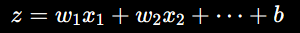

Here, `intercept_` is (b).

---

## 3. classes_

Shows the class labels the model learned.

### Syntax

```python
model.classes_
```

Example:

```text
array([0, 1])
```

For multiclass:

```text
array([0, 1, 2])
```

Useful when interpreting `predict_proba()` output because the columns correspond to the order in `classes_`.

---

## 4. n_features_in_

Returns the number of input features used during training.

### Syntax

```python
model.n_features_in_
```

Example:

```text
30
```

Useful for validation and debugging.

---

## 5. feature_names_in_

Available when training with a **Pandas DataFrame**.

### Syntax

```python
model.feature_names_in_
```

Example:

```text
['age',
 'salary',
 'experience']
```

Useful for:

* Feature importance analysis.
* Model documentation.

---

## 6. n_iter_

Shows how many iterations the optimizer actually used.

### Syntax

```python
model.n_iter_
```

Example:

```text
[18]
```

Interpretation:

* Small value → Model converged quickly.
* Equal to `max_iter` → The optimizer may have hit the iteration limit. If you also receive a `ConvergenceWarning`, consider increasing `max_iter`.

---

# Complete Example

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=500)

# Train
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Probabilities
prob = model.predict_proba(X_test)

# Accuracy
acc = model.score(X_test, y_test)

# Attributes
print(model.coef_)
print(model.intercept_)
print(model.classes_)
print(model.n_features_in_)
print(model.n_iter_)
```

---

# Summary

| Category          | Most Important    |
| ----------------- | ----------------- |
| Training          | `fit()`           |
| Prediction        | `predict()`       |
| Probability       | `predict_proba()` |
| Accuracy          | `score()`         |
| Feature Weights   | `coef_`           |
| Bias              | `intercept_`      |
| Class Labels      | `classes_`        |
| Convergence Check | `n_iter_`         |

# Section 4 — End-to-End Workflow

This section puts everything together into a complete scikit-learn workflow.

---

# Workflow Diagram

```text
Load Dataset
      │
      ▼
Split Data
      │
      ▼
Scale Features
      │
      ▼
Create LogisticRegression Model
      │
      ▼
Train Model (fit)
      │
      ▼
Predict
      │
      ├──────────────┐
      ▼              ▼
predict()     predict_proba()
      │              │
      └──────┬───────┘
             ▼
      Evaluate Model
```

---

# Complete Example

We'll use the **Breast Cancer Dataset** from scikit-learn.

It is a **binary classification** dataset.

| Class | Meaning   |
| ----- | --------- |
| 0     | Malignant |
| 1     | Benign    |

---

## Step 1 — Import Libraries

```python
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
```

---

## Step 2 — Load Dataset

```python
data = load_breast_cancer()

X = data.data
y = data.target
```

---

## Step 3 — Train-Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

---

## Step 4 — Feature Scaling

Logistic Regression is an optimization-based algorithm.

Different feature scales can slow convergence.

Therefore, scale **after** train-test split.

```python
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
```

> **Remember:** Never call `fit_transform()` on the test set. Use only `transform()`.

---

## Step 5 — Create Model

```python
model = LogisticRegression(
    random_state=42,
    max_iter=500
)
```

---

## Step 6 — Train Model

```python
model.fit(X_train, y_train)
```

After this step, the model learns:

* Feature coefficients
* Bias
* Decision boundary

---

## Step 7 — Predict Classes

```python
y_pred = model.predict(X_test)
```

Example output:

```text
[1 0 1 1 0 0 1]
```

These are the predicted class labels.

---

## Step 8 — Predict Probabilities

```python
y_prob = model.predict_proba(X_test)
```

Example:

```text
[
 [0.01 0.99]
 [0.88 0.12]
 [0.25 0.75]
]
```

Interpretation:

| Output        | Meaning                    |
| ------------- | -------------------------- |
| `[0.01,0.99]` | 99% probability of Class 1 |
| `[0.88,0.12]` | 88% probability of Class 0 |

To get only the probability of Class 1:

```python
positive_prob = model.predict_proba(X_test)[:, 1]
```

This is commonly used for:

* ROC Curve
* Precision-Recall Curve
* Threshold tuning

---

## Step 9 — Evaluate Accuracy

```python
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)
```

Or simply:

```python
print(model.score(X_test, y_test))
```

Both produce the same accuracy value.


---

# Important Notes

| Note                                    | Explanation                                           |
| --------------------------------------- | ----------------------------------------------------- |
| Scale numerical features                | Helps the optimizer converge faster and more reliably |
| Split before scaling                    | Prevents data leakage                                 |
| Increase `max_iter` if needed           | Fixes most `ConvergenceWarning`s                      |
| `predict()` returns labels              | e.g., `0`, `1`                                        |
| `predict_proba()` returns probabilities | e.g., `[0.2, 0.8]`                                    |
| `score()` returns accuracy              | Equivalent to `accuracy_score()` for classifiers      |
| Use `random_state`                      | Ensures reproducible results                          |

---

# Common Errors

| Mistake                                       | Why It Happens                                    | Solution                                                                 |
| --------------------------------------------- | ------------------------------------------------- | ------------------------------------------------------------------------ |
| Scaling before train-test split               | Information from the test set leaks into training | Split first, then scale                                                  |
| Using `fit_transform()` on the test set       | The scaler learns from test data                  | Use `transform()` only                                                   |
| Ignoring `ConvergenceWarning`                 | Optimizer didn't finish within `max_iter`         | Increase `max_iter` (e.g., 500 or 1000)                                  |
| Using regression metrics like MAE or RMSE     | Logistic Regression is a classifier               | Use classification metrics such as accuracy, precision, recall, F1-score |
| Forgetting to scale features                  | Slower convergence or convergence issues          | Apply `StandardScaler` for numerical features                            |
| Expecting `predict()` to return probabilities | `predict()` returns class labels only             | Use `predict_proba()` when probabilities are needed                      |

---

# Mini Workflow Checklist

```text
✔ Load Dataset

✔ Train-Test Split

✔ Scale Features

✔ Create LogisticRegression

✔ fit()

✔ predict()

✔ predict_proba()

✔ Evaluate Accuracy
```

In [51]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score


# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(
    random_state=42,
    max_iter=500
)

# Train
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Probability prediction
y_prob = model.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nCoefficients")
print(model.coef_)

print("\nIntercept")
print(model.intercept_)

print("\nClasses")
print(model.classes_)

Accuracy : 0.9736842105263158
Precision : 0.9722
Recall    : 0.9859
F1 Score  : 0.9790

Coefficients
[[-0.43190368 -0.38732553 -0.39343248 -0.46521006 -0.07166728  0.54016395
  -0.8014581  -1.11980408  0.23611852  0.07592093 -1.26817815  0.18887738
  -0.61058302 -0.9071857  -0.31330675  0.68249145  0.17527452 -0.3112999
   0.50042502  0.61622993 -0.87984024 -1.35060559 -0.58945273 -0.84184594
  -0.54416967  0.01611019 -0.94305313 -0.77821726 -1.20820031 -0.15741387]]

Intercept
[0.44558453]

Classes
[0 1]


### **ROC and AUC**

FPR: [0.         0.         0.         0.02325581 0.02325581 0.04651163
 0.04651163 1.        ]
TPR: [0.         0.01408451 0.90140845 0.90140845 0.98591549 0.98591549
 1.         1.        ]
ROC AUC: 0.99737962659679


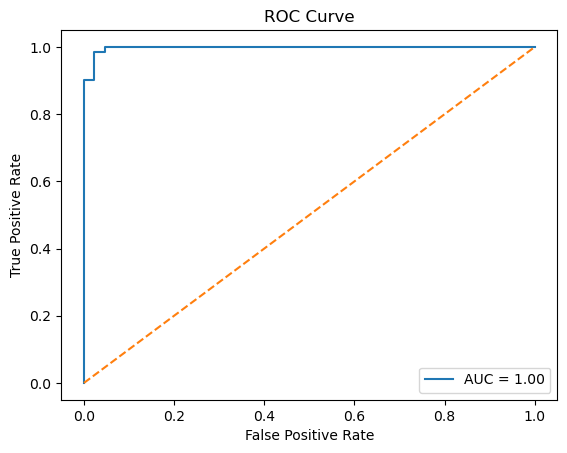

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of positive class
y_score = model.predict_proba(X_test)[:, 1]   # .predict_proba returns and numpy array with 2 elements in each numy array in each and [1] means for class 1

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# AUC Score
auc = roc_auc_score(y_test, y_score)

print(f"FPR: {fpr}")
print(f"TPR: {tpr}")

print("ROC AUC:", auc)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### **Confusion Matrix**

[[41  2]
 [ 1 70]]


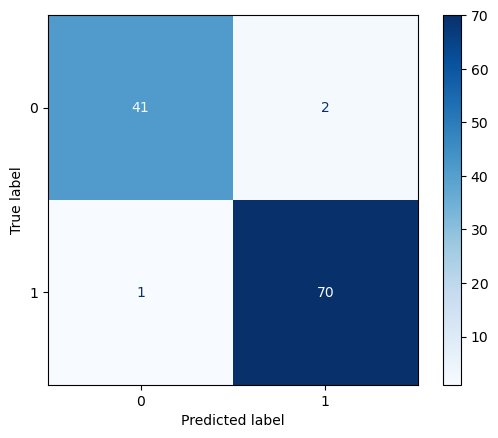

In [53]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=None,
    sample_weight=None
)
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',

)

## **Cross Validation**

In [54]:
from sklearn.model_selection import(
    KFold,
    StratifiedKFold ,
    cross_val_score,
    cross_validate,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline(
    steps=[
        ('scaler' , StandardScaler()),
        ('classifier' , LogisticRegression(max_iter=500))
    ]
)



cv_kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# For KFold

scores1 = cross_val_score(
    estimator=pipe,
    X=X,
    y=y,
    cv = cv_kf
)

scores2 = cross_validate(
    estimator=pipe,
    X=X,
    y=y,
    cv = cv_kf,
    scoring = ['accuracy' , 'f1_macro' , 'precision_macro' , 'recall_macro']
)


# We can access only cross_validate() like this not cross_val_score() as it dont return dictionary
print("Accuracy :", scores2["test_accuracy"].mean())
print("Precision:", scores2["test_precision_macro"].mean())
print("Recall   :", scores2["test_recall_macro"].mean())
print("F1 Score :", scores2["test_f1_macro"].mean())





Accuracy : 0.9771464058376029
Precision: 0.9766121637000256
Recall   : 0.9747918442216644
F1 Score : 0.9754909383701953
